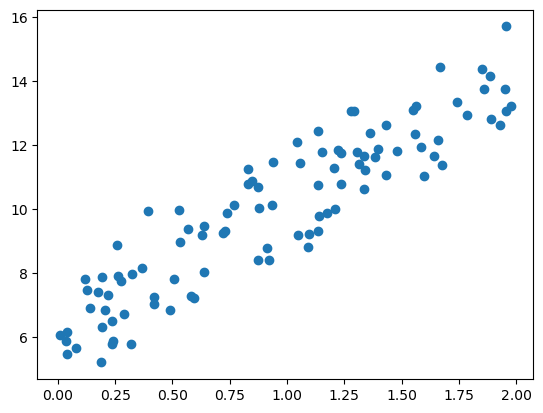

In [31]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = 2 * np.random.rand(100, 1)
# 100개의 행과 1개의 열로 이루어진 2차원 행렬을 의미한다.
y = 6 + 4 * X + np.random.randn(100, 1)
plt.scatter(X, y)

In [32]:
# 경사하강법을 코드로 이해하기!
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred))/N
    # square(): 그 오차를 각각 제곱하는 역할이다. 
    return cost 

In [33]:
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    N = len(y)
    w1_update = np.zeros_like(w1)
    # zeros_like()는 무슨 함수인가?
    w0_update = np.zeros_like(w0)
    y_pred = np.dot(X, w1.T) + w0
    diff = y-y_pred

    w0_factors = np.ones((N, 1))

    w1_update =-(2/N)*learning_rate*(np.dot(X.T, diff))
    w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))
    return w1_update, w0_update

In [34]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X = np.arange(9).reshape(-1, 3)
print(X)

poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print(poly_ftr)

[[0 1 2]
 [3 4 5]
 [6 7 8]]
[[ 1.  0.  1.  2.  0.  0.  0.  1.  2.  4.]
 [ 1.  3.  4.  5.  9. 12. 15. 16. 20. 25.]
 [ 1.  6.  7.  8. 36. 42. 48. 49. 56. 64.]]


In [35]:
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y

X = np.arange(4).reshape(2, 2)
print('일차 다항식 계수 feature: \n', X)
# Numpy 배열과 list 자료형을 구분하라!
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 다항식 계수 feature: 
 [[0 1]
 [2 3]]
삼차 다항식 결정값: 
 [  5 125]


In [36]:
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n',poly_ftr)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(poly_ftr, y)
print('Polynomial 회귀 계수\n', np.round(model.coef_, 5))
print('Polynomial 회귀 shape:', model.coef_.shape)
print('숨겨둔 값:', model.intercept_)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [-0.       0.18018  0.18018  0.36036  0.54054  0.72072  0.72072  1.08108
  1.62162  2.34234]
Polynomial 회귀 shape: (10,)
숨겨둔 값: 1.7567567567567792


In [37]:
from sklearn.pipeline import Pipeline
import numpy as np

model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
# 겉은 리스트로 묶고, 안은 튜플로 (별칭, 실제 머신러닝 객체) 를 설정한다.
X = np.arange(4).reshape(-1, 2)
y = polynomial_func(X)

model = model.fit(X, y)
# 10개의 피처와 정답 y를 활용하여 최적의 가중치를 계산한다.

print(model.named_steps['linear'])
# model 자체는 pipeline box고, 회귀 모델 그 자체가 아니다. 그래서 named_steps 까지 붙여서 coef 를 찾아내는 것이다.
print('회귀 계수', np.round(model.named_steps['linear'].coef_, 2))

LinearRegression()
회귀 계수 [-0.    0.18  0.18  0.36  0.54  0.72  0.72  1.08  1.62  2.34]


In [38]:
# p.324 보스턴 주택 가격 회귀 구현

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

boston = pd.read_csv('boston.csv')
boston = boston.rename(columns={'MEDV':'PRICE'})
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


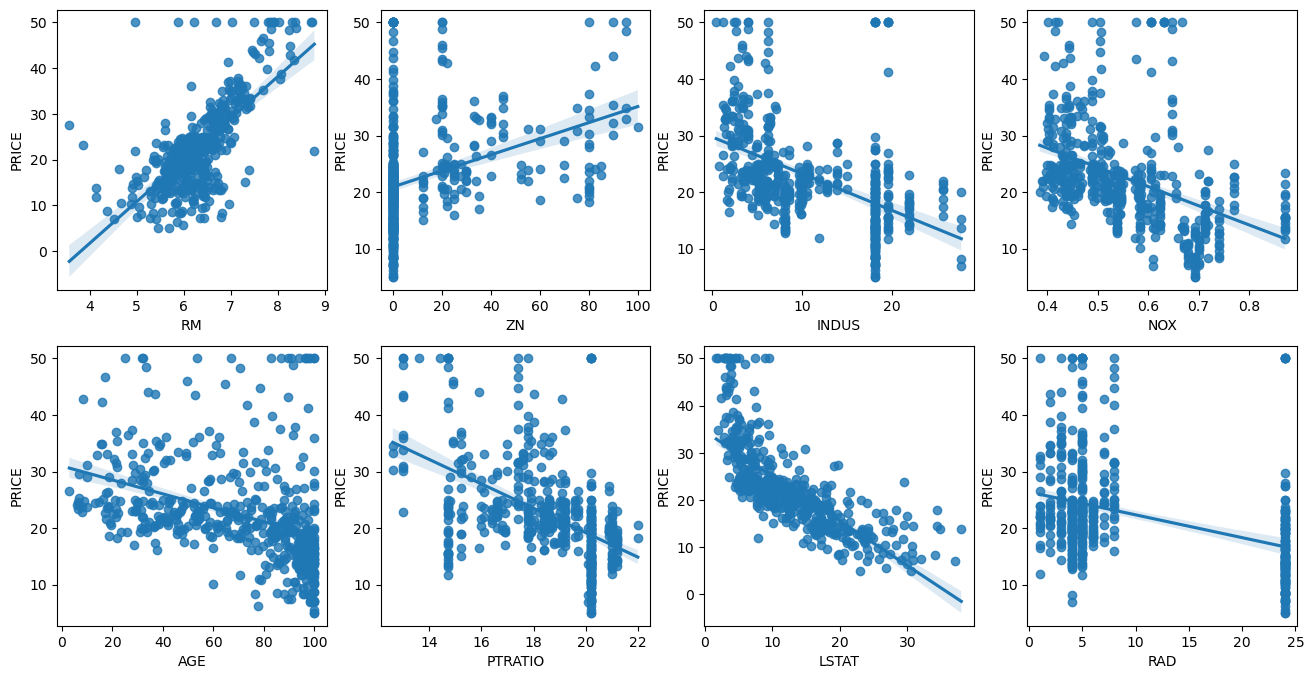

In [39]:
fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)
lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    sns.regplot(x=feature, y='PRICE', data=boston, ax=axs[row][col])

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

target = boston['PRICE']
input = boston.drop(['PRICE'], axis=1, inplace=False)

train_input, test_input, train_target, test_target = train_test_split(input, target, random_state=42, test_size=0.3)

lr = LinearRegression()
lr.fit(train_input, train_target)
test_pred = lr.predict(test_input)
mse = mean_squared_error(test_target, test_pred)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE : {1:.3F}'.format(mse, rmse))
print('Val Score : {0:.3f}'.format(r2_score(test_target, test_pred)))

MSE : 21.517, RMSE : 4.639
Val Score : 0.711


In [41]:
print(lr.intercept_)
print(np.round(lr.coef_, 1))

31.631084035693522
[ -0.1   0.    0.    3.1 -15.4   4.1  -0.   -1.4   0.2  -0.   -0.9   0.
  -0.5]


In [42]:
coeff = pd.Series(data=np.round(lr.coef_, 1), index=train_input.columns)
coeff.sort_values(ascending=True)

NOX       -15.4
DIS        -1.4
PTRATIO    -0.9
LSTAT      -0.5
CRIM       -0.1
ZN          0.0
INDUS       0.0
AGE        -0.0
TAX        -0.0
B           0.0
RAD         0.2
CHAS        3.1
RM          4.1
dtype: float64

In [43]:
from sklearn.model_selection import cross_val_score

y_target = boston['PRICE']
X_input = boston.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

neg_mse_scores = cross_val_score(lr, X_input, y_target, scoring='neg_mean_squared_error', cv=5)
# 애초에 scoring에 neg_ 를 앞에 붙일 수밖에 없다. 
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(np.round(neg_mse_scores, 2))
print(np.round(rmse_scores, 2))
print('{0:.3f}'.format(avg_rmse))

[-12.46 -26.05 -33.07 -80.76 -33.31]
[3.53 5.1  5.75 8.99 5.77]
5.829


In [47]:
from sklearn.pipeline import Pipeline

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
print(X)

y = true_fun(X) + np.random.randn(n_samples) * 0.1
print(y)


[0.0202184  0.07103606 0.0871293  0.11827443 0.14335329 0.38344152
 0.41466194 0.4236548  0.43758721 0.46147936 0.52184832 0.52889492
 0.54488318 0.5488135  0.56804456 0.60276338 0.63992102 0.64589411
 0.71518937 0.77815675 0.78052918 0.79172504 0.79915856 0.83261985
 0.87001215 0.891773   0.92559664 0.94466892 0.96366276 0.97861834]
[ 1.0819082   0.87027612  1.14386208  0.70322051  0.78494746 -0.25265944
 -0.22066063 -0.26595867 -0.4562644  -0.53001927 -0.86481449 -0.99462675
 -0.87458603 -0.83407054 -0.77090649 -0.83476183 -1.03080067 -1.02544303
 -1.0788268  -1.00713288 -1.03009698 -0.63623922 -0.86230652 -0.75328767
 -0.70023795 -0.41043495 -0.50486767 -0.27907117 -0.25994628 -0.06189804]



Degree 15 회귀 계수는 [-2.98293000e+03  1.03899370e+05 -1.87416114e+06  2.03716252e+07
 -1.44873341e+08  7.09315818e+08 -2.47066009e+09  6.24561742e+09
 -1.15676664e+10  1.56895176e+10 -1.54006289e+10  1.06457467e+10
 -4.91378551e+09  1.35919950e+09 -1.70381195e+08] 입니다.
Degree 15 MSE 는 182618860.9149443 입니다.


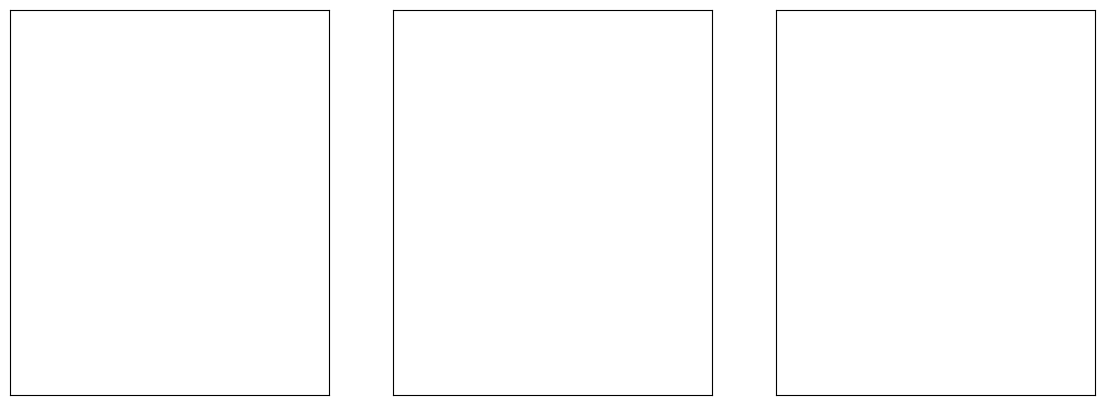

In [49]:
plt.figure(figsize=(14, 5)) 
degrees = [1, 4, 15]

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1) #i+1을 왜 하는 걸까?
    plt.setp(ax, xticks=(), yticks=())

# 개별 degree별로 Polynomial 변환합니다.

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)

# 교차 검증으로 다항 회귀를 평가합니다.

    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)

# Pipeline을 구성하는 세부 객체를 접근하는 named_steps[‘객체명’]을 이용해 회귀계수 추출

coefficients = pipeline.named_steps['linear_regression'].coef_
print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))

# 0 부터 1 까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
# 테스트 데이터 세트에 회귀 예측올 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.

X_test = np.linspace(0, 1, 100) #이 함수는 또 뭘까?
